## ¿Puede un joven pagar la hipoteca en 2022?

**Fase 3 · limpieza y cruzamiento (guía).** Corte de 2022: ¿cuánta hipoteca puede sostener un joven? Se toma la oferta real de productos de ese año, el precio mediano de cada región y el salario joven estimado, y se calcula la cuota mensual que le correspondería.

In [1]:
import sys
from pathlib import Path
_ROOT = Path.cwd()
while not any((_ROOT / c).exists() for c in ['db', 'data']) and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT / 'script'))
from proyecto import graficos
display(graficos.fig_fases())

<Figure size 1344x364 with 1 Axes>

## 1. Buscar la raíz del proyecto

In [2]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

PROYECTO = Path.cwd()
while not any((PROYECTO / c).exists() for c in ['db', 'data']) and PROYECTO != PROYECTO.parent:
    PROYECTO = PROYECTO.parent

sys.path.insert(0, str(PROYECTO / 'script'))
from proyecto import config
from proyecto import (cargar, limpiar, diagnostico, transformaciones, cruces,
                      indicadores, validacion, graficos)

def presentar(fig):
    display(fig)

print('raiz del proyecto:', PROYECTO.name)
print('fuentes en data/crudo:', [p.name for p in config.DATA_CRUDO.glob('*.csv')])

raiz del proyecto: mineria
fuentes en data/crudo: ['Average_UK_houseprices_and_salary.csv', 'Income_by_age_and_gender.csv', 'MET_Office_Weather_Data.csv', 'UK_Mortgage_Rate.csv']


## 2. La fórmula de la cuota (PMT)

Cuota fija mensual sobre el 90 % del precio, a 25 años.

$\text{cuota} = P \cdot \dfrac{r/12}{1-(1+r/12)^{-25\cdot 12}}$

Detalle importante: el precio de 2022 está en libras nominales y el salario de F4 en GBP-2020, así que el precio se deflacta (CPI del Banco de Inglaterra, dic 2020 a dic 2022 ≈ 13,7 %).

In [3]:
h = cargar.cargar_hipotecas()
h_limpio, _ = limpiar.limpiar_hipotecas(h)
tasa = h_limpio['tasa_inicial_pct'].astype('float64')
lim = diagnostico.limites_iqr(tasa)['limite_superior']
h_limpio['tasa_inicial_pct'] = diagnostico.winsorizar(tasa, lim)
print('tasa inicial media (winsorizada, IQR):', f"{h_limpio['tasa_inicial_pct'].mean():.2f} %")
print('comisiones media   :', f"GBP {h_limpio['comisiones_total'].mean():,.0f}")
print('plazo (anios)      :', int(h_limpio['plazo_anios'].unique()[0]), '| LTV:', int(config.LTV * 100), '%')
print('deflactor 2022->2020 :', config.DEFLACTOR_2022_A_2020)

tasa inicial media (winsorizada, IQR): 6.04 %
comisiones media   : GBP 1,116
plazo (anios)      : 25 | LTV: 90 %
deflactor 2022->2020 : 1.137


## 3. ¿Cuánto cobra cada tipo de producto?

In [4]:
h_limpio.groupby('tipo', observed=True)['tasa_inicial_pct'].agg(['mean', 'median', 'count']).round(2)

,mean,median,count
tipo,,,
discounted,4.06,4.05,1185
fixed,6.60,6.32,5933
tracker,4.08,3.64,430
variable,5.69,5.79,248


## 4. Esfuerzo por región con el corte 2022

In [5]:
st = transformaciones.serie_salario_joven(cargar.cargar_precios_salario(),
          transformaciones.salario_joven(cargar.cargar_ingreso_edad(),
                                            cargar.cargar_precios_salario())[1])
precios_region = transformaciones.agregado_precios_region(cargar.cargar_precios_limpios())
tabla = indicadores.hipoteca_2022(precios_region, h_limpio, st)
display(tabla.round(0))

,region,precio_mediana,salario_joven_region,precio_real_2020,tasa_inicial_pct,cuota_mensual,salario_joven_mensual,cuota_pct_salario,accesible
0,North East,149950.0,21550.0,131882.0,6.0,772.0,1796.0,0.0,False
1,North West,195000.0,23071.0,171504.0,6.0,1002.0,1923.0,1.0,False
2,Yorkshire and The Humber,190000.0,22311.0,167106.0,6.0,977.0,1859.0,1.0,False
3,Wales,199950.0,22818.0,175858.0,6.0,1028.0,1901.0,1.0,False
4,West Midlands,235000.0,23071.0,206684.0,6.0,1207.0,1923.0,1.0,False
5,East Midlands,240000.0,23325.0,211082.0,6.0,1233.0,1944.0,1.0,False
6,South West,309500.0,24085.0,272208.0,6.0,1589.0,2007.0,1.0,False
7,East of England,340000.0,25607.0,299033.0,6.0,1745.0,2134.0,1.0,False
8,South East,377500.0,26874.0,332014.0,6.0,1937.0,2240.0,1.0,False
9,London,515000.0,31691.0,452946.0,6.0,2641.0,2641.0,1.0,False


## 5. La figura del esfuerzo

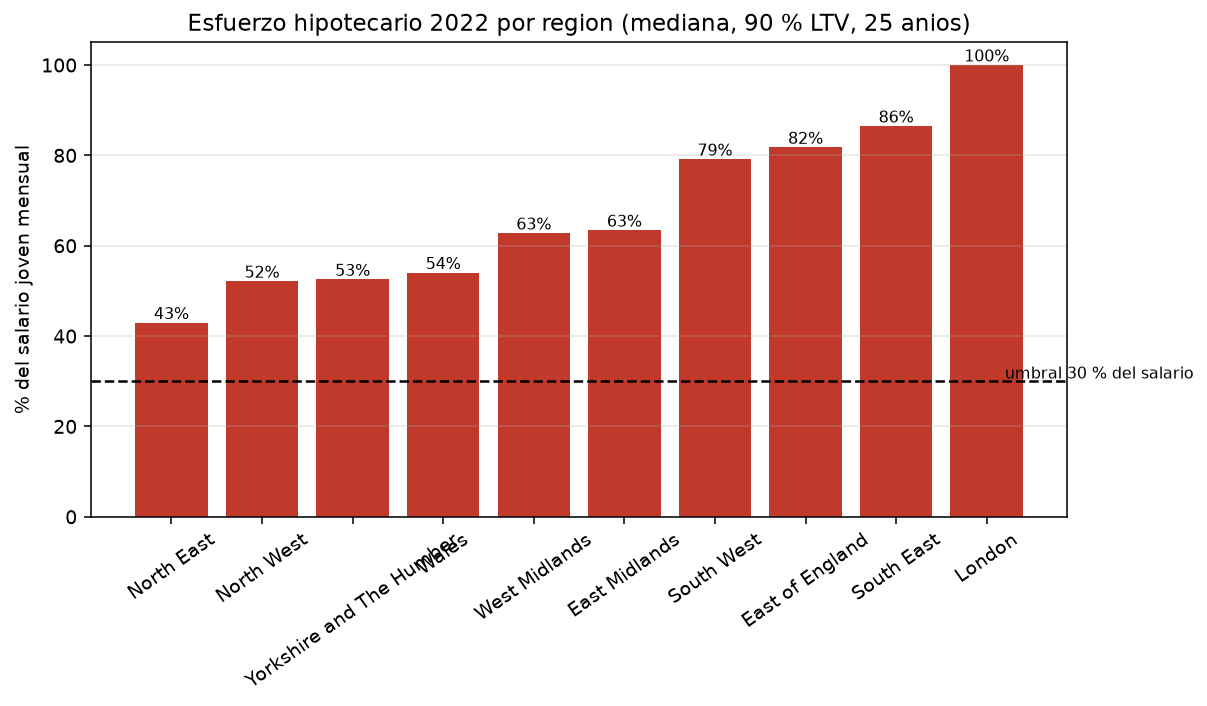

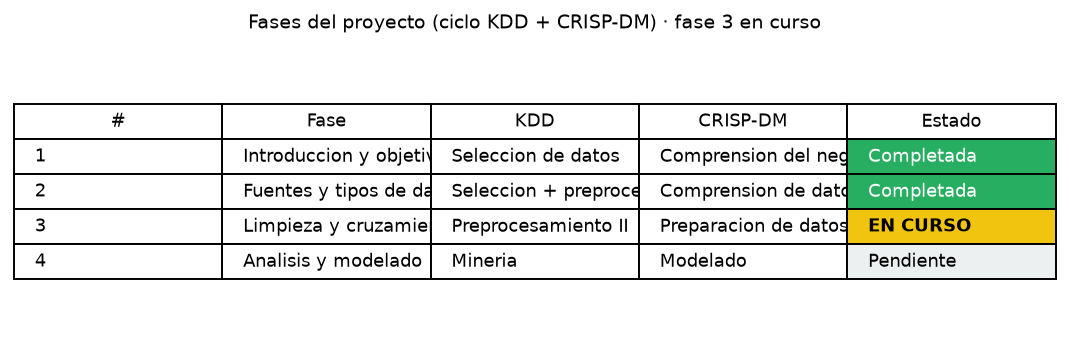

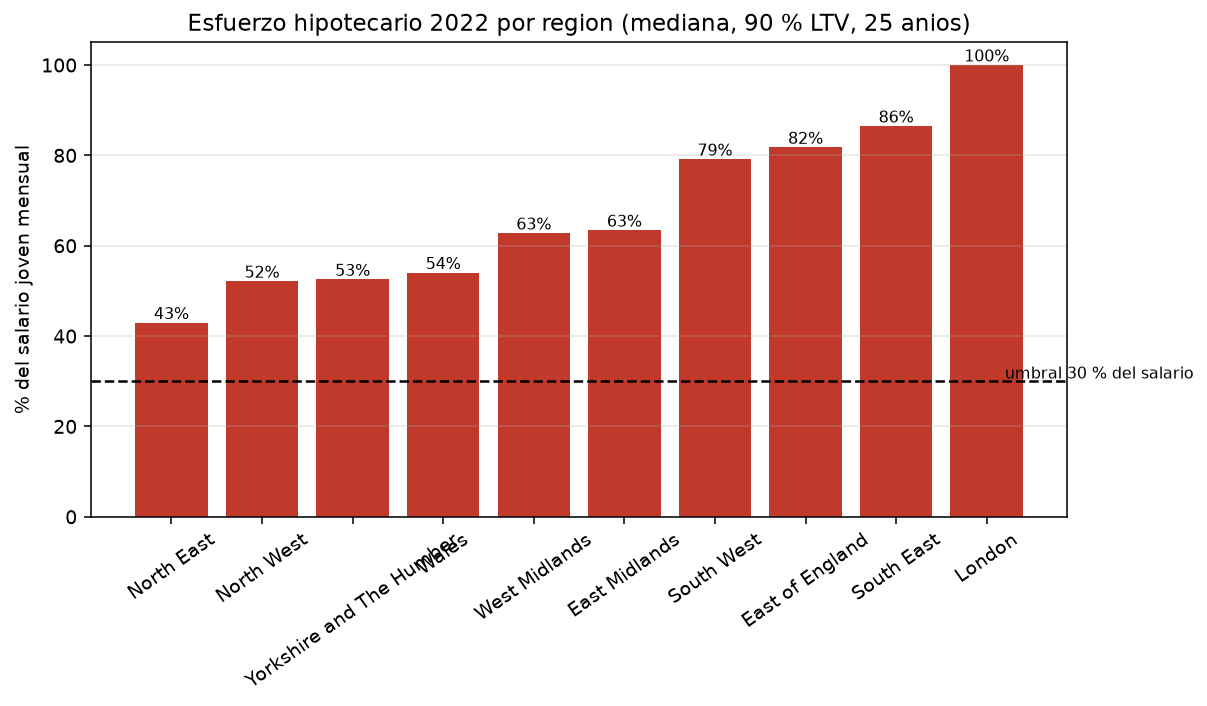

In [6]:
presentar(graficos.fig_hipoteca_2022(tabla))

## ¿Qué tan accesible es, en números?

Ni una sola región baja del 30 % del salario como cuota. El recorrido va del **43 % (North East)** y se dispara hasta el **100 % en London**, donde la cuota se come el salario mensual completo, aun deflactando el precio a GBP-2020. Dicho sin vueltas: en 2022 el crédito es el eslabón que le cierra la puerta de compra a un joven.

## Cierre del cuaderno

La tasa aquí es la **media winsorizada con IQR** (6,04 %). Si se hubieran dejado los 762 productos atípicos, el esfuerzo habría subido de forma injusta.